# Bertrand's Paradox: What Does ‘Random’ Mean?

The Bertrand paradox is generally presented as follows: Consider an equilateral triangle inscribed in a circle. Suppose a chord of the circle is chosen at random. What is the probability that the chord is longer than a side of the triangle?

Bertrand came up with three different ways to choose a random chord, each of which leads to a different answer!

In this notebook, we simulate all three methods and compare their long-run probabilities. The important lesson is not that probability is inconsistent; it is that *choose a chord at random* does not specify a unique probability model. Each construction weights the possible chords differently.

For a unit circle, the inscribed equilateral triangle has side length $\sqrt{3}$. A chord counts as long when its length exceeds this value. Because these are Monte Carlo estimates, the results fluctuate slightly each time the notebook runs.

## Bertrand's three constructions

### 1. Random endpoints: $P=1/3$

Choose two points independently and uniformly on the circumference, then join them. Rotational symmetry lets us hold the first endpoint fixed. Let $\theta$ be the smaller central angle between the endpoints; it is uniform from 0 to $\pi$. The chord length is

$$L=2\sin\left(\frac{\theta}{2}\right).$$

The condition $L>\sqrt{3}$ is equivalent to $\theta>2\pi/3$. The favorable interval has width $\pi-2\pi/3=\pi/3$ out of a total width $\pi$, so

$$P(L>\sqrt{3})=\frac{\pi/3}{\pi}=\boxed{\frac13}.$$

### 2. Random radius and distance: $P=1/2$

Choose a radius at random, select a point uniformly along that radius, and draw the chord through the point perpendicular to the radius. If $r$ is the point's distance from the center, then $r$ is uniform from 0 to 1 and

$$L=2\sqrt{1-r^2}.$$

A chord is longer than $\sqrt{3}$ when $r<1/2$. Half of the uniformly sampled radial interval satisfies this condition, giving

$$P(L>\sqrt{3})=\boxed{\frac12}.$$

### 3. Random midpoint: $P=1/4$

Choose a point uniformly by area anywhere inside the circle and use it as the midpoint of a chord. The same geometric condition applies: the chord is long when its midpoint lies within $r<1/2$. This time, however, points at larger radii are more common because an annulus contains more area than one near the center. The favorable midpoints occupy a disk of radius $1/2$, so the area ratio is

$$P(L>\sqrt{3})=\frac{\pi(1/2)^2}{\pi(1)^2}=\boxed{\frac14}.$$

All three answers are mathematically correct for their respective sampling rules. The paradox is that the original phrase *a chord chosen at random* does not tell us which probability distribution over chords to use. The simulations below implement each construction and recover these three theoretical values.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

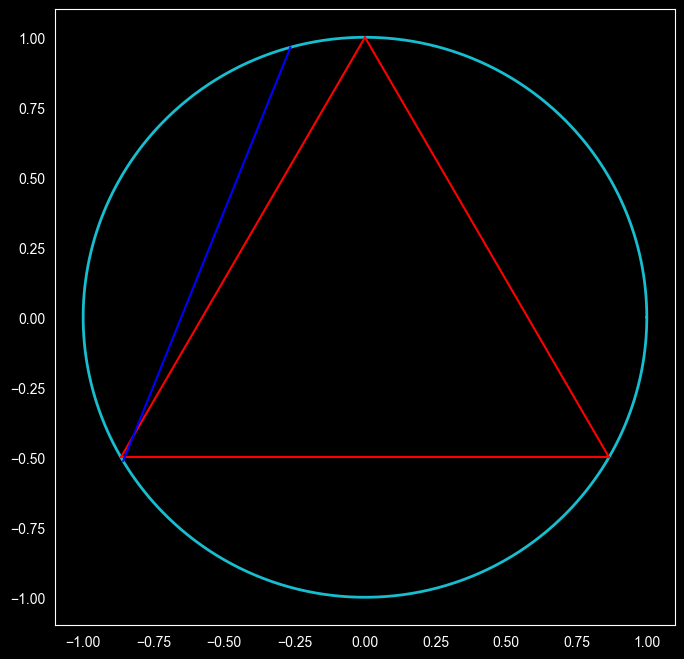

In [2]:
fig, ax = plt.subplots(1,1,figsize=(8,8))

# Generate two random points on the circle
theta1 = np.random.uniform(0, 2*np.pi)
xi1 = np.cos(theta1)
yi1 = np.sin(theta1)

theta2 = np.random.uniform(0, 2*np.pi)
xi2 = np.cos(theta2)
yi2 = np.sin(theta2)

length1 = np.sqrt((xi1-xi2)**2 + (yi1-yi2)**2)

thetac = np.linspace(0, 2*np.pi, 1000)
xc = np.cos(thetac)
yc = np.sin(thetac)
ax.plot(xc, yc, color='tab:cyan', linewidth=2)
ax.grid(False)

ax.plot([0, np.sqrt(3)/2], [1, -0.5], 'r')
ax.plot([0, -np.sqrt(3)/2], [1, -0.5], 'r')
ax.plot([-np.sqrt(3)/2, np.sqrt(3)/2], [-0.5, -0.5], 'r')

ax.plot([xi1, xi2], [yi1, yi2], 'b')

plt.show()

### Method 1

The first method is called the random-endpoints method. The algorithm is as follows:

1. Choose two random points on the circle, at random positions.
2. Calculate the length of the chord that joins them.

The exact probability is $1/3$: after fixing one endpoint by rotational symmetry, the second endpoint must lie within an arc covering one third of the circle.

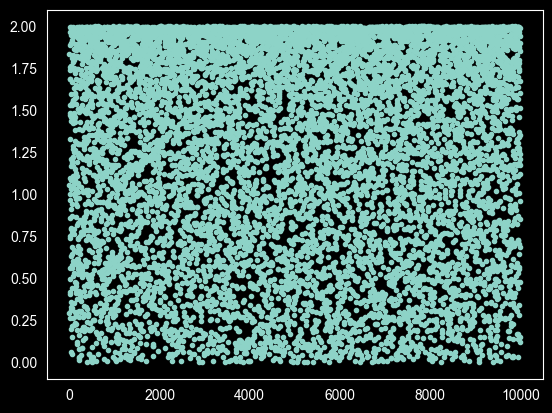

In [3]:
# Generate random points on the circle

n = 10000   # number of points

theta1 = np.random.uniform(0, 2*np.pi, n)
xi1 = np.cos(theta1)
yi1 = np.sin(theta1)

theta2 = np.random.uniform(0, 2*np.pi, n)
xi2 = np.cos(theta2)
yi2 = np.sin(theta2)

length1 = np.sqrt((xi1-xi2)**2 + (yi1-yi2)**2)

plt.plot(np.arange(n), length1, '.')
plt.grid(False)


Method 1 probability = 0.3385


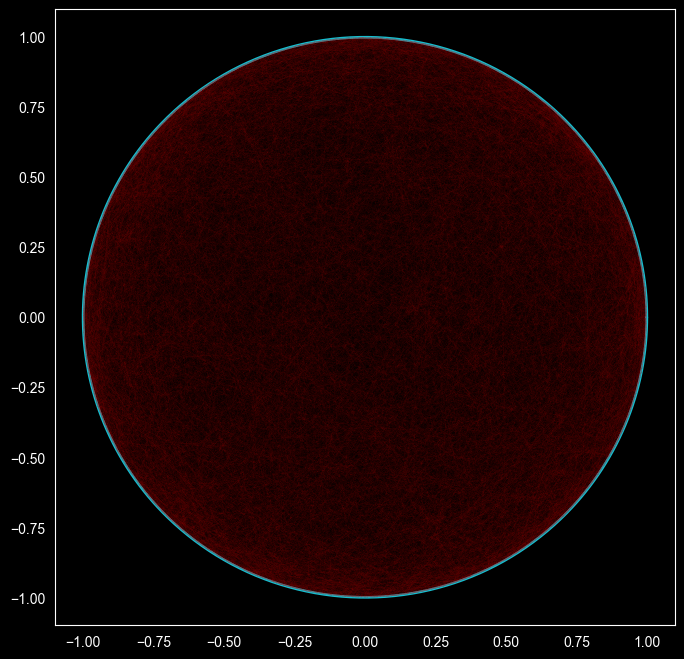

In [4]:
fig, ax = plt.subplots(1,1,figsize=(8,8))

thetac = np.linspace(0, 2*np.pi, 1000)
xc = np.cos(thetac)
yc = np.sin(thetac)
ax.plot(xc, yc, color='tab:cyan', linewidth=2)
ax.grid(False)

count1 = 0
for i in range(n):
    if length1[i] > np.sqrt(3):
        count1 += 1
    ax.plot([xi1[i], xi2[i]], [yi1[i], yi2[i]], 'r', linewidth=0.01)

print(f"Method 1 probability = {count1/n}")
plt.show()

### Method 2

The second method is called the random radial method. The algorithm is as follows:

1. Choose a random point on the circle.
2. Construct the radius from the centre of the circle to this point.
3. Choose a random point on this radius.
4. Construct the chord perpendicular to the radius at this point.
5. Calculate the length of the chord.

A chord is longer than $\sqrt{3}$ exactly when its distance from the center is less than $1/2$. Since this method samples that distance uniformly from 0 to 1, its exact probability is $1/2$.

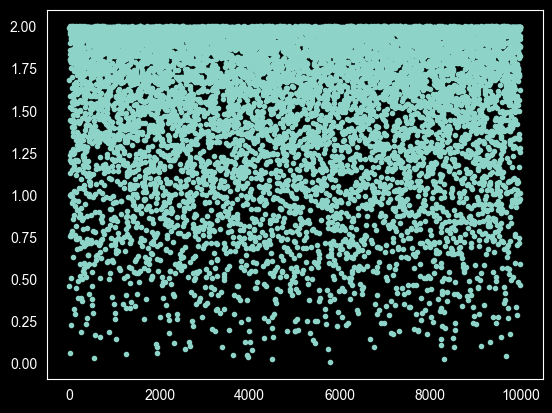

In [5]:
# Step 1 and 2
theta = np.random.uniform(0, 2*np.pi, n)
x = np.cos(theta)
y = np.sin(theta)

# Step 3
fraction = np.random.uniform(0, 1, n)
x1 = fraction*x
y1 = fraction*y

m = -x1/y1
b = y1 - m*x1

# Step 4
# From Wolfram-Alpha, find intersection of circle of radius 1 and the line y = mx + b

xint1 = (-np.sqrt(-b**2+m**2+1) - b*m)/(m**2+1)
yint1 = m*xint1 + b

xint2 = (np.sqrt(-b**2+m**2+1) - b*m)/(m**2+1)
yint2 = m*xint2 + b

length2 = np.sqrt((xint1-xint2)**2 + (yint1-yint2)**2)

plt.plot(np.arange(n), length2, '.')
plt.grid(False)

#print (xint1, yint1)
#print (xint2, yint2)

Method 2 probability = 0.4996


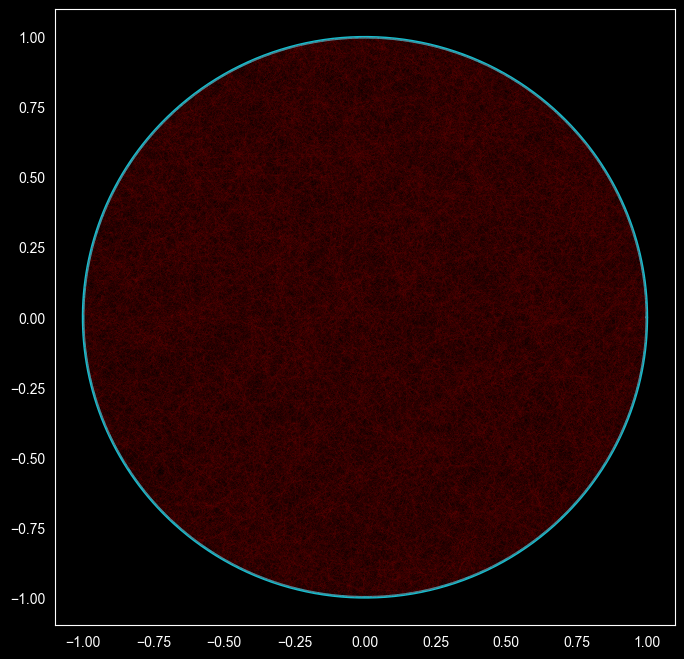

In [6]:
fig, ax = plt.subplots(1,1,figsize=(8,8))

thetac = np.linspace(0, 2*np.pi, 1000)
xc = np.cos(thetac)
yc = np.sin(thetac)
ax.plot(xc, yc, color='tab:cyan', linewidth=2)
ax.grid(False)

count2 = 0
for i in range(n):
    if length2[i] > np.sqrt(3):
        count2 += 1
    ax.plot([xint1[i], xint2[i]], [yint1[i], yint2[i]], 'r', linewidth=0.01)

print(f"Method 2 probability = {count2/n}")
plt.show()

### Method 3

The third method is called the random midpoint method. The algorithm is as follows:

1. Choose a random point within the circle.
2. Construct the chord with this point as its midpoint.
3. Calculate the length of the chord.

Again the midpoint must lie within radius $1/2$, but now points are sampled uniformly by area. The favorable disk has one quarter of the unit disk's area, so the exact probability is $1/4$.

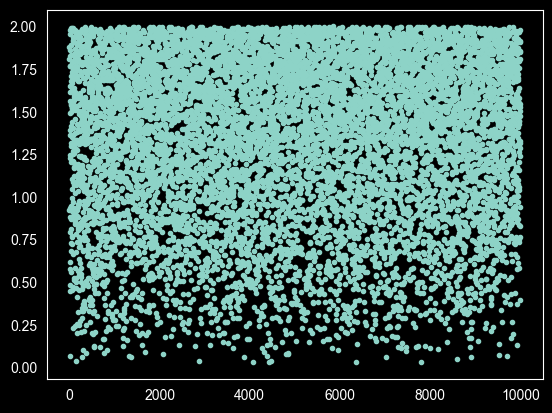

In [7]:
# Step 1
chosen = 0
length3 = np.zeros(n)
xint3 = np.zeros(n)
xint4 = np.zeros(n)
yint3 = np.zeros(n)
yint4 = np.zeros(n)

while chosen < n:
    x1 = np.random.uniform(-1, 1)
    y1 = np.random.uniform(-1, 1)
    radius = np.sqrt(x1**2 + y1**2)

    if radius <= 1:

        # Step 2
        m = -x1/y1
        b = y1 - m*x1

        xint3[chosen] = (-np.sqrt(-b**2+m**2+1) - b*m)/(m**2+1)
        yint3[chosen] = m*xint3[chosen] + b

        xint4[chosen] = (np.sqrt(-b**2+m**2+1) - b*m)/(m**2+1)
        yint4[chosen] = m*xint4[chosen] + b

        length3[chosen] = np.sqrt((xint3[chosen]-xint4[chosen])**2 + (yint3[chosen]-yint4[chosen])**2)
        chosen += 1

plt.plot(np.arange(n), length3, '.')
plt.grid(False)


Method 3 probability = 0.2517


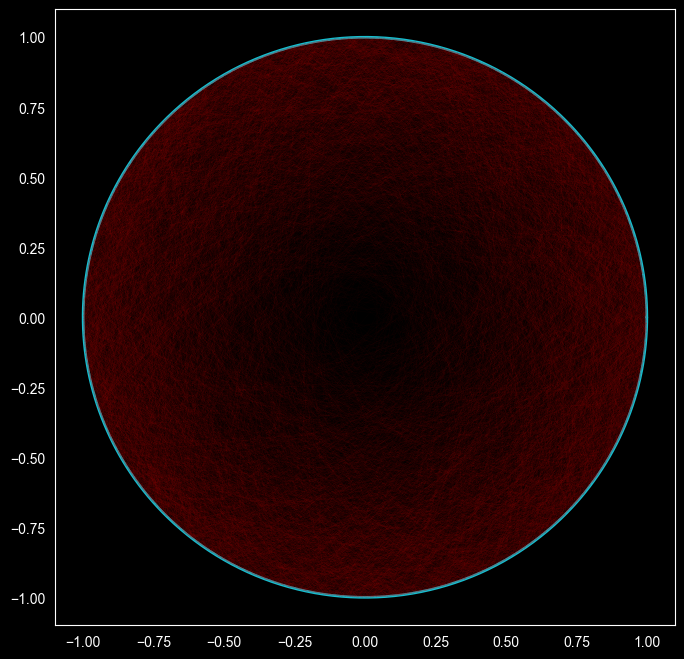

In [8]:
fig, ax = plt.subplots(1,1,figsize=(8,8))

thetac = np.linspace(0, 2*np.pi, 1000)
xc = np.cos(thetac)
yc = np.sin(thetac)
ax.plot(xc, yc, color='tab:cyan', linewidth=2)
ax.grid(False)

count3 = 0
for i in range(n):
    if length3[i] > np.sqrt(3):
        count3 += 1
    ax.plot([xint3[i], xint4[i]], [yint3[i], yint4[i]], 'r', linewidth=0.01)

print(f"Method 3 probability = {count3/n}")
plt.show()

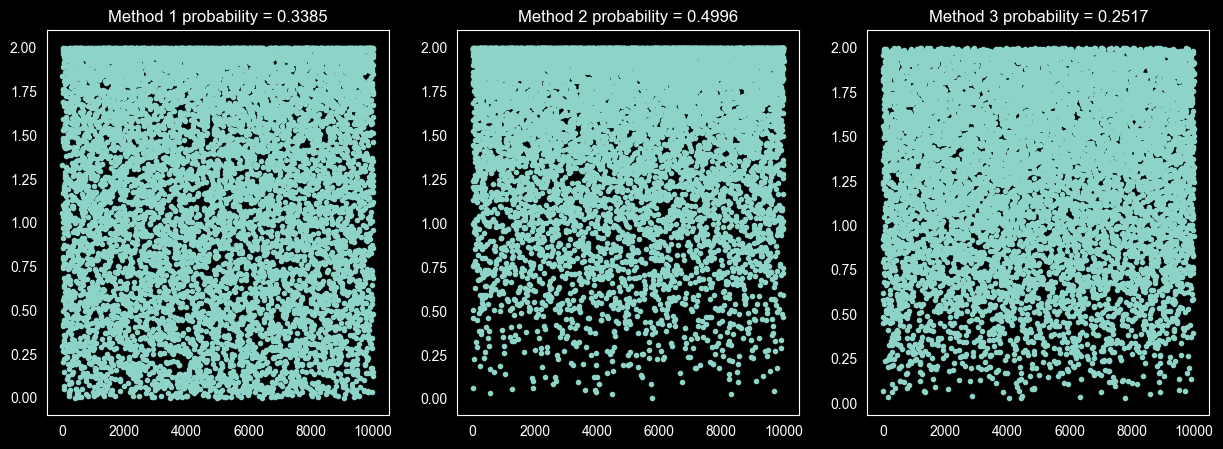

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(np.arange(n), length1, '.')
ax[0].set_title(f"Method 1 probability = {count1/n}")
ax[1].plot(np.arange(n), length2, '.')
ax[1].set_title(f"Method 2 probability = {count2/n}")
ax[2].plot(np.arange(n), length3, '.')
ax[2].set_title(f"Method 3 probability = {count3/n}")
for axis in ax:
    axis.grid(False)
plt.show()

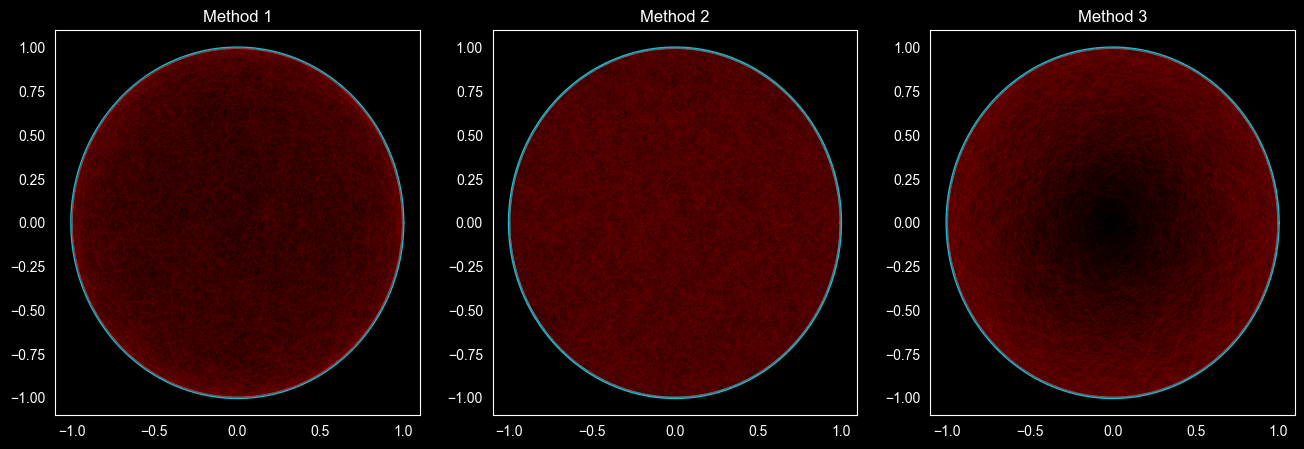

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

ax[0].set_title("Method 1")
ax[0].plot(xc, yc, color='tab:cyan', linewidth=2)
for i in range(n):
    ax[0].plot([xi1[i], xi2[i]], [yi1[i], yi2[i]], 'r', linewidth=0.01)

ax[1].set_title("Method 2")
ax[1].plot(xc, yc, color='tab:cyan', linewidth=2)
for i in range(n):
    ax[1].plot([xint1[i], xint2[i]], [yint1[i], yint2[i]], 'r', linewidth=0.01)

ax[2].set_title("Method 3")
ax[2].plot(xc, yc, color='tab:cyan', linewidth=2)
for i in range(n):
    ax[2].plot([xint3[i], xint4[i]], [yint3[i], yint4[i]], 'r', linewidth=0.01)

for axis in ax:
    axis.grid(False)

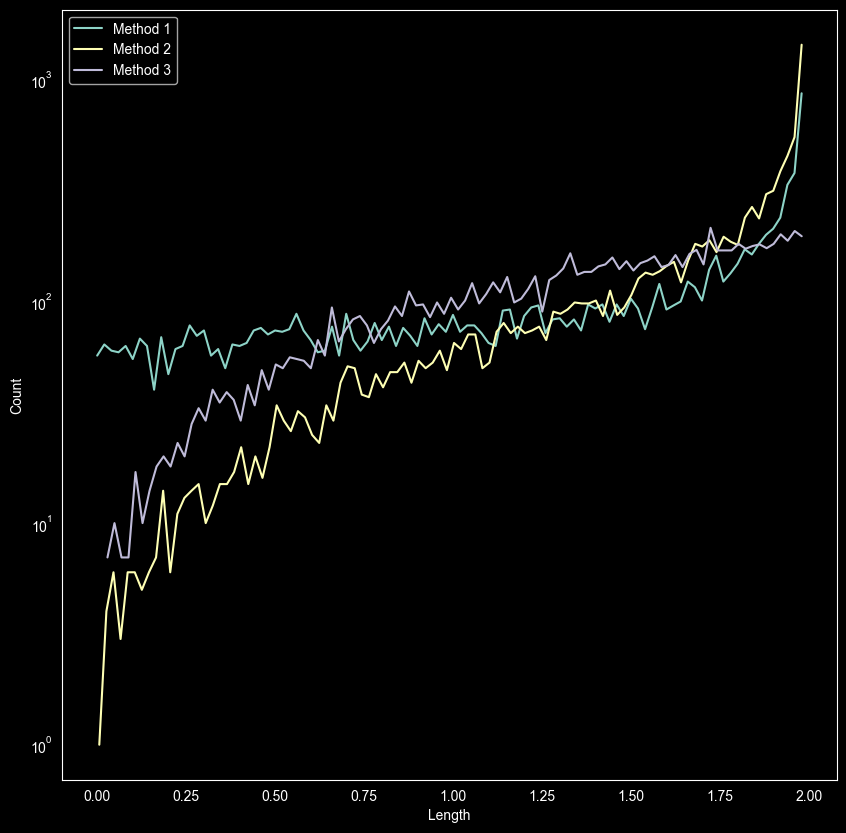

In [11]:
fig = plt.figure(figsize=(10, 10))
counts, bins = np.histogram(length1, bins=100)
plt.plot(bins[:-1], counts, label="Method 1")
counts, bins = np.histogram(length2, bins=100)
plt.plot(bins[:-1], counts, label="Method 2")
counts, bins = np.histogram(length3, bins=100)
plt.plot(bins[:-1], counts, label="Method 3")
plt.yscale('log')
plt.ylabel("Count")
plt.xlabel("Length")
plt.legend()
plt.grid(False)
plt.show()


## Interpretation

The three simulations should approach $1/3$, $1/2$, and $1/4$. None is uniquely correct until the sampling procedure is specified. This is Bertrand's paradox: geometric symmetry alone does not determine a probability measure on the set of chords.

Increase `n` and watch the estimates stabilize. Typical Monte Carlo error decreases only as $1/\sqrt{n}$, so gaining one extra decimal place generally requires about 100 times as many samples.